[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/04_pretrain_sjepa_on_normal.ipynb)

# 04. Train S-JEPA: normal gait first, then one condition at a time

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

## The question this notebook answers

What does a skeleton JEPA encoder learn from **normal** gait alone, and what happens to that representation when four condition groups are folded into the same model one at a time?

To answer that we need a baseline that exists before any condition label can influence the weights. So Stage 0 trains from fresh weights on normal sequences only and is saved to disk before a single non-normal pose tensor is loaded for optimization. Stages 1 through 4 then continue the very same model, adding one condition per stage and replaying every earlier condition.

This notebook produces a representation and a diagnostic trace. It does not decide whether the representation is useful. Notebook 05 inspects the geometry and notebook 06 reads it out with classifiers, and both of those notebooks reach much more cautious conclusions than the training curves alone would suggest.

## What you need before you start

1. **A pose cache from notebook 02.** The loader below refuses to run against a cache that does not match the locked cohort exactly, so run notebook 02 to completion first.
2. **`GAVD_MODE` set in `experiments/sjepa/gavd6-pm/.env`.** `smoke` uses hand-authored synthetic motions that exercise the code paths and have no pathophysiological meaning. `real` uses the cached GAVD poses. Every number quoted in this notebook comes from a completed `real` run.
3. **A decision about the augmented-normal cohort.** `SJEPA_INCLUDE_AUGMENTED_NORMAL=1` folds in self-annotated YouTube normal clips and diverts every output it touches to an `*_augmented` filename, so the locked canonical artifacts are never overwritten. The completed run recorded here had the flag on.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd6-pm/.env`.

## What it produces

- One checkpoint per stage, plus a copy of the Stage 4 state as `sjepa_curriculum_final_augmented.pt`. Each checkpoint carries a SHA-256 experiment fingerprint and the fingerprint of its parent stage, so the lineage can be verified rather than assumed.
- `curriculum_training_history_augmented.csv`, one row per epoch with every loss term and diagnostic.
- `curriculum_stage_summary_augmented.csv` and `curriculum_training_diagnostics_augmented.png`.
- `normal_pose_coverage_augmented.csv`, the landmark-coverage audit of the Stage 0 cohort.

Notebooks 05 and 06 both load the final checkpoint and reject it if the curriculum is incomplete, the stage order is wrong, the mask whitelist differs, or the run mode does not match.

## Read these four definitions before any output appears

The abbreviated epoch line printed during training packs four very different quantities into one row, and readers routinely misread three of them. Fix the meanings now.

| Name | What it is |
|---|---|
| **VICReg** | Only the label-free invariance, variance-hinge, and covariance regularizer, computed on **projected student** features. It never sees a condition label. |
| **Group loss** | A **separate**, label-aware term, equal to within-condition compactness **plus** a centroid-margin penalty. It is exactly zero in Stage 0 and active in Stages 1 through 4. |
| the `group` log field | Only the **centroid-margin penalty**. It is not the complete group loss, because the compactness half is omitted from the short display. |
| the `std` log field | The mean feature standard deviation of **unprojected EMA-teacher** embeddings over the whole active corpus, measured after the epoch's updates. It is a **diagnostic**, not a VICReg component and not a loss. It is never backpropagated and it has no target value. |

## Hard constraints this notebook enforces

- No motion-aware mask is ever computed. Prediction targets are sampled uniformly at random from eligible tokens.
- Only BlazePose indices 11, 12, and 23 through 32 may become hidden targets. An assertion fails the run if any other index enters the mask.
- The Stage 0 checkpoint is written before any condition data is loaded for optimization.
- The EMA target encoder never receives a gradient, and an assertion checks that after every backward pass.

## The nine steps

1. Point the notebook at the data and choose the run mode.
2. Fix the vocabulary: landmarks, cohort census, preprocessing, the mask sampler, the model, and the loaders.
3. Choose the training scale and understand why "epoch" is an ambiguous unit here.
4. Load normal sequences only, and apply the recorded augmented-normal selection rule.
5. Build the one model that continues through every stage.
6. Define the objective, term by term.
7. Run Stage 0 and save the normal-only anchor.
8. Run Stages 1 through 4 with balanced replay.
9. Plot the whole-curriculum diagnostics and read them without overclaiming.


## Step 1 of 9: point the notebook at the data and choose the run mode

**What we are about to do.** Resolve the repository root, load `.env`, decide between `smoke` and `real` mode, and create the cache and artifact directories.

**Why this comes first.** Every later cell writes into `ARTIFACT_DIR`, and `ARTIFACT_DIR` depends on the mode. If the mode were decided after data loading, a smoke run could overwrite real artifacts. Resolving it here makes that impossible.

**What to look at in the output.** Four lines. `mode:` must read `real` for a result you intend to cite. `artifacts:` is the directory every checkpoint and CSV lands in; note it down, because notebooks 05 and 06 read from the same place. In the completed run these read `mode: real` and `artifacts: .../gavd6/work/artifacts/real`.

**What we may conclude.** Only that the environment is wired up. Nothing has been measured yet.

The figure in the following cell is the training step we are about to implement: mask eligible tokens, encode the visible remainder, predict the hidden teacher features, and compare.


In [1]:
from pathlib import Path
import json
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
POSE_CACHE_CONTRACT = json.loads(
    (TUTORIAL_DIR / "pose_cache_contract.json").read_text()
)
CURRENT_EXTRACTION_VERSION = POSE_CACHE_CONTRACT["current_extraction_version"]
COMPATIBLE_EXTRACTION_VERSIONS = frozenset(
    POSE_CACHE_CONTRACT["compatible_extraction_versions"]
)
if CURRENT_EXTRACTION_VERSION not in COMPATIBLE_EXTRACTION_VERSIONS:
    raise ValueError("Current pose extraction version must be compatible")

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/data/gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


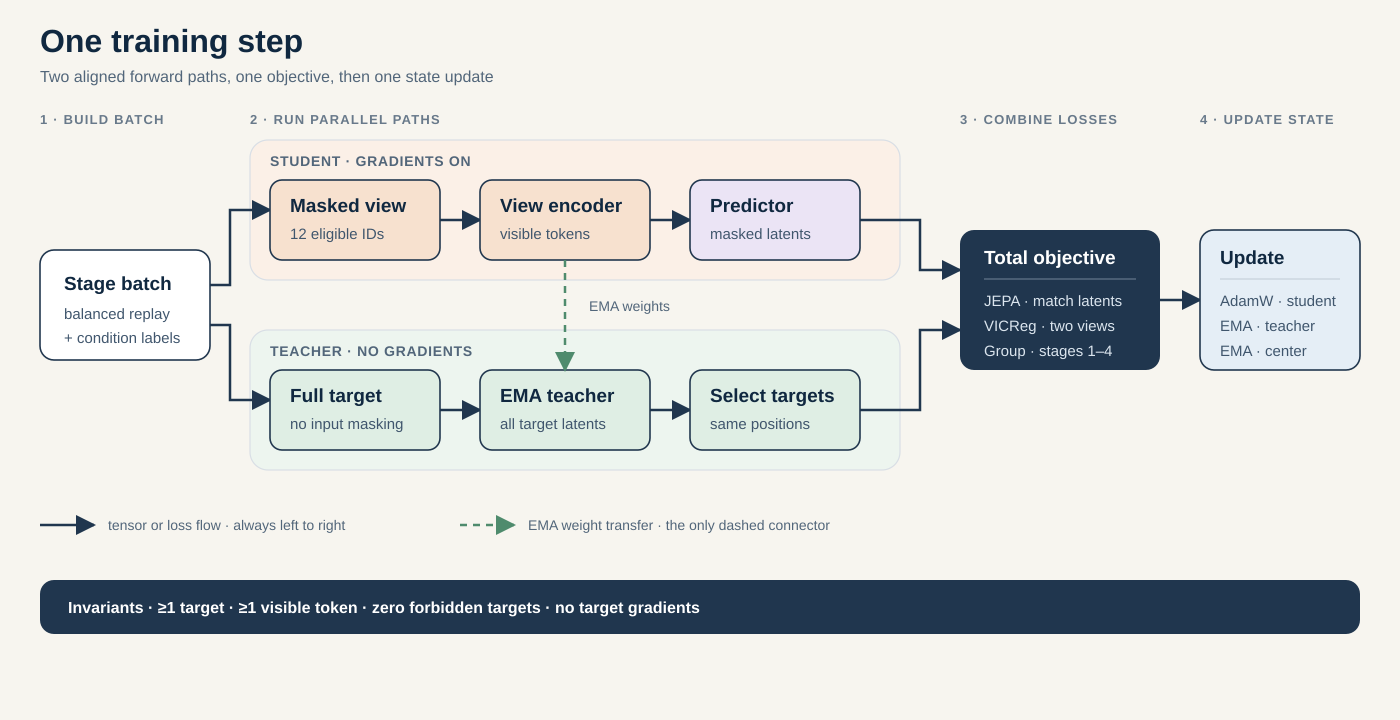

In [2]:
show_tutorial_svg("06_training_step.svg")


## Step 2 of 9: fix the vocabulary before anything is trained

**What we are about to do.** Run seven definition cells back to back. They introduce no results. They fix the landmark names, the cohort census, the synthetic smoke fixtures, the preprocessing chain, the mask sampler, the model classes, and the two pose-cache loaders.

**Why this comes before training.** Each of these is a choice that determines what the reported numbers can mean. Reading them now is what lets you interpret an epoch line later instead of just watching it scroll.

### 2a. The 33 landmark names, and the 12 that may be hidden

`BLAZEPOSE_33` names every landmark index so that later code can refer to `LEFT_ANKLE` rather than `27`. `MASK_KEYPOINTS` is the whitelist of indices eligible to become prediction targets: the left and right shoulders, hips, knees, ankles, heels, and foot indices. It is expanded and de-duplicated from `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`, and applying it to this five-group experiment is a project rule, not a validated diagnostic rule. Two assertions check that the list is sorted, has no duplicates, and names exactly the twelve landmarks we intend.

### 2b. The locked cohort census

`EXPECTED_SEQUENCE_COUNTS` records how many canonical GAVD sequences each condition folder must contain: normal 12, Parkinson's 9, stroke 12, myopathic 47, cerebral palsy 16, for 96 in total. The cell counts the CSV files on disk and raises if any folder disagrees. `CURRICULUM` then declares the five ordered stages and asserts that each stage's active set is exactly the conditions up to and including the one it adds, so the ordering cannot silently drift.

Why bother? Because a silent cohort change would move every number in notebooks 04, 05, and 06 at once, and nothing downstream would notice. The census makes that failure loud.

### 2c. Synthetic fixtures for smoke mode

`synthetic_gait_sequence` builds hand-authored motions with a reduced swing amplitude for Parkinson's, a damped left leg for stroke, and so on. Its own docstring calls it a code-path fixture, not a physiological disease simulation. **Never quote a smoke-mode number as a gait result.**

### 2d. Preprocessing, in seven steps

`prepare_sequence` chains the transformations that turn a raw `[time, 33, 4]` pose array, three coordinates plus a visibility score, into a fixed tensor:

1. mark a joint valid when visibility is at least 0.45;
2. interpolate internal coordinate gaps of at most four frames, while preserving the original validity mask so an interpolated point can never become a prediction target;
3. subtract the pelvis center;
4. divide by a shoulder-and-hip width scale;
5. replace remaining invalid coordinates with an explicit zero sentinel;
6. resize coordinates and validity to 64 frames;
7. group every four frames into one time patch.

The result has 16 time patches by 33 joints, so 528 possible joint-time tokens per sequence.

### 2e. The mask rule, and why 0.60 does not mean "60 percent per sample"

`uniform_neurologic_mask` samples the hidden targets. This is the single most misread setting in the notebook, so read the code and not the name of the constant. The configuration says `mask_fraction = 0.60`, but 0.60 is applied to the **smallest** eligible-token count in the batch:

1. count valid eligible tokens in every sample of the batch;
2. take the **minimum** of those counts;
3. multiply that minimum by 0.60 and round down;
4. cap it so at least one eligible token stays visible;
5. sample that one common number, uniformly and without replacement, in **every** sample.

A common target count is what lets the encoder pack all samples into one tensor. The consequence is that any sample with more than the minimum number of valid tokens realizes a fraction **below** 0.60. This is not a rounding detail: averaged over each stage's epochs, the realized mean eligible fraction was **0.549 in Stage 0** and **0.421 in Stage 4**, because later stages pool in sequences with poorer landmark coverage and so pull the batch minimum down. `mask_audit` records the per-batch minimum, mean, and maximum so the realized fraction is auditable rather than assumed.

Note what the sampler never reads: position, motion magnitude, velocity, acceleration, or any learned motion score. Targets are uniform over eligible tokens, and assertions reject every forbidden index.

### 2f. The model: encoder, predictor, EMA teacher

Three components and two helper functions:

- `SkeletonPatchEncoder` embeds each joint-time patch, adds a learned time position and a learned joint position, and runs a Transformer stack. When given a keep mask it drops the hidden tokens entirely rather than zeroing them.
- `SkeletonPredictor` receives the visible features, fills every hidden slot with a learned mask token, adds positions, and predicts a feature vector for each hidden slot.
- `SJEPAGait` holds the trainable **view encoder**, a gradient-free **target encoder** that begins as an exact copy of it, the predictor, and a running `target_center` buffer. `update_target` moves the target encoder toward the view encoder by an EMA step; `update_center` tracks the mean teacher feature so the loss can be centered.
- `sjepa_cross_entropy` is the JEPA objective: sharpen and center the teacher features into a probability distribution, sharpen the prediction into log-probabilities, and take the cross entropy. `cosine_ema` schedules the EMA momentum from its start value up to 1.0 over the stage.
- `geometric_view` makes the two augmented views VICReg needs, applying one small rotation about the vertical axis and one small translation per sample. **Left-right flipping defaults to off**, because laterality can matter for stroke; if it were enabled, the code both reflects the coordinates and swaps every left-right landmark pair.

### 2g. The two loaders, and the augmented-normal selection contract

`pose_records_from_cache` loads the canonical cache and validates it hard: required keys present, shape `[time, 33, 4]`, stored condition matching the folder, stored sequence ID matching the filename and the source CSV, a compatible extraction version, and frame counts aligned with the pose array. Any mismatch raises with instructions for re-extracting.

`augmented_normal_records` loads the opt-in augmented cohort, and its selection rule is the part worth reading twice. The cohort is **not** defined by which files happen to sit in the pose directory. It is defined by `augmented_pose_extraction_report.csv` plus one recorded threshold, `MIN_AUGMENTED_NEURO_OBSERVED = 0.45`. The report contains **64** audited candidates. A candidate is accepted when its neurologic-landmark coverage is at least 0.45, which accepts **63** of them; one 44-frame candidate with coverage **0.027** is rejected. The loader then raises if any accepted ID is missing from disk, or if any file on disk was not accepted.

Why does an explicit rule matter? Because "the files that are there" is not reproducible. Someone re-running this notebook a year from now, on a directory that gained or lost a file, would train on a different cohort and never know. A recorded threshold applied to a recorded report means the cohort can be reconstructed exactly, and means a rejection is a documented decision rather than a missing file. The augmented windows use automatic MediaPipe bounding boxes; they are not canonical GAVD annotations and are not independently clinically verified.

`cohort_artifact_name` implements the divert-on-flag rule for sidecar files, keyed on whether augmented records were actually loaded, so an enabled flag with an empty cache still writes canonical names.

**What we may conclude from Step 2.** Nothing empirical. These cells only make the later numbers interpretable.


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
PROGRESSIVE_CONDITIONS = CONDITIONS[1:]
COHORT_ROOT = PROJECT_ROOT / "data" / "gavd"
EXPECTED_SEQUENCE_COUNTS = {
    "normal": 12,
    "parkinsons": 9,
    "stroke": 12,
    "myopathic": 47,
    "cerebralpalsy": 16,
}
EXPECTED_SEQUENCE_IDS = {
    condition: {path.stem for path in (COHORT_ROOT / condition).glob("*.csv")}
    for condition in CONDITIONS
}
for condition, expected_count in EXPECTED_SEQUENCE_COUNTS.items():
    actual_count = len(EXPECTED_SEQUENCE_IDS[condition])
    if actual_count != expected_count:
        raise ValueError(
            f"Locked cohort definition for {condition} has {actual_count} IDs; "
            f"expected {expected_count}: {COHORT_ROOT / condition}"
        )
CURRICULUM = [
    {"stage": 0, "name": "normal_only", "add": "normal", "conditions": ["normal"]},
    {"stage": 1, "name": "add_parkinsons", "add": "parkinsons", "conditions": CONDITIONS[:2]},
    {"stage": 2, "name": "add_stroke", "add": "stroke", "conditions": CONDITIONS[:3]},
    {"stage": 3, "name": "add_myopathic", "add": "myopathic", "conditions": CONDITIONS[:4]},
    {"stage": 4, "name": "add_cerebralpalsy", "add": "cerebralpalsy", "conditions": CONDITIONS[:5]},
]
assert [stage["add"] for stage in CURRICULUM] == CONDITIONS
assert all(stage["conditions"] == CONDITIONS[:stage["stage"] + 1] for stage in CURRICULUM)


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    The configured fraction is applied to the smallest eligible count in the
    batch, then that common target count is used for every sample. A sample
    with more valid targets therefore realizes a fraction below the setting.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [9]:
import json

POSE_CACHE_CONTRACT = json.loads(
    (TUTORIAL_DIR / "pose_cache_contract.json").read_text()
)
COMPATIBLE_EXTRACTION_VERSIONS = frozenset(
    POSE_CACHE_CONTRACT["compatible_extraction_versions"]
)
POSE_CACHE_REQUIRED_KEYS = {
    "sequence", "sequence_id", "video_id", "condition",
    "frame_numbers", "crop_bounds", "fps", "source_csv",
    "source_video", "pose_model", "pose_model_sha256",
    "extraction_version",
}


def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        available = {path.stem: path for path in folder.glob("*.npz")}
        expected = EXPECTED_SEQUENCE_IDS[condition]
        missing_ids = sorted(expected.difference(available))
        unexpected_ids = sorted(set(available).difference(expected))
        if missing_ids or unexpected_ids:
            raise ValueError(
                f"Canonical {condition} pose cache does not match the locked cohort at "
                f"{folder}: expected {len(expected)}, found {len(available)}; "
                f"missing IDs={missing_ids[:8]}"
                f"{' ...' if len(missing_ids) > 8 else ''}; "
                f"unexpected IDs={unexpected_ids[:8]}"
                f"{' ...' if len(unexpected_ids) > 8 else ''}. "
                f"In {TUTORIAL_DIR / '.env'} set GAVD_ARTIFACT_DIR to an "
                "experiment-local directory, GAVD_EXTRACT_POSES=1, "
                "GAVD_EXTRACT_CONDITIONS=all, and GAVD_MAX_SEQUENCES=0; "
                "restart the kernel and rerun notebook 02."
            )
        for sequence_id in sorted(expected):
            path = available[sequence_id]
            data = np.load(path, allow_pickle=False)
            missing = POSE_CACHE_REQUIRED_KEYS.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            stored_sequence_id = str(data["sequence_id"].item())
            if stored_sequence_id != sequence_id:
                raise ValueError(
                    f"Pose sequence ID {stored_sequence_id} does not match {path.name}"
                )
            source_csv_id = Path(str(data["source_csv"].item())).stem
            if source_csv_id != sequence_id:
                raise ValueError(
                    f"Pose source CSV ID {source_csv_id} does not match {sequence_id}"
                )
            extraction_version = str(data["extraction_version"].item())
            if extraction_version not in COMPATIBLE_EXTRACTION_VERSIONS:
                raise ValueError(
                    f"Unsupported extraction version {extraction_version} in {path}; "
                    f"accepted versions are {sorted(COMPATIBLE_EXTRACTION_VERSIONS)}. "
                    "If this archive came from the current notebook 02, check that both "
                    "notebooks use the same pose_cache_contract.json before re-extracting."
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": stored_sequence_id,
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": extraction_version,
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    print(f"Real pose corpus: {len(records)} sequences")
    return records


In [10]:
# --- Optional augmentation-normal cohort (self-annotated YouTube clips) -------
# A SEPARATE, opt-in pool of normal sequences whose bounding boxes were
# auto-detected with MediaPipe Pose (provenance: pose-auto bbox), extracted with
# the identical notebook-02 contract into a parallel pose dir. This exists to
# break the "normal = 1 source video" ceiling (see notes/04_improvement_plan.md
# lever C1) and make a video-disjoint normal split possible.
#
# Turned OFF by default: with the flag unset this notebook loads exactly the
# locked 12-sequence / 1-video canonical cohort, unchanged, and writes every
# canonical artifact (checkpoint AND sidecars) under its canonical name. Set
# SJEPA_INCLUDE_AUGMENTED_NORMAL=1 in gavd6-pm/.env to fold the cohort in;
# an enabled run diverts EVERY output it touches to an *_augmented name so the
# locked canonical artifacts are never overwritten.
INCLUDE_AUGMENTED_NORMAL = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"
MIN_AUGMENTED_NEURO_OBSERVED = 0.45


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    """Load the separately-counted augmentation-normal pose cache, if present.

    Uses the same required-key contract as pose_records_from_cache; the augmented
    .npz files carry those keys plus provenance (cohort/bbox_source/clip_id).
    The extraction report is the selection contract. A candidate must meet
    the recorded neurologic-coverage threshold, so the cohort never depends
    on which files happen to remain in the pose directory.
    Returns [] when the flag is off or the cache is absent, so the canonical run
    is never affected.
    """
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is enabled, but the active artifact "
            f"root has no augmented poses at {folder}. If a completed legacy "
            "cohort exists, run notes/migrate_augmented_pose_artifacts.py first; "
            "otherwise run notes/annotate_normal_clips.py and then "
            "notes/extract_augmented_poses.py."
        )
    if not AUGMENTED_REPORT.is_file():
        raise FileNotFoundError(
            f"Missing augmentation selection contract: {AUGMENTED_REPORT}. "
            "Migrate the report with notes/migrate_augmented_pose_artifacts.py "
            "or regenerate it with notes/extract_augmented_poses.py."
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    required_report = {"sequence_id", "status", "neuro_observed"}
    missing_report = required_report.difference(report.columns)
    if missing_report:
        raise ValueError(f"Augmentation report missing {sorted(missing_report)}")
    if report["sequence_id"].astype(str).duplicated().any():
        raise ValueError("Augmentation report contains duplicate sequence IDs")
    candidates = report[~report["status"].astype(str).str.startswith("error")].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce")
        >= MIN_AUGMENTED_NEURO_OBSERVED
    )
    selected_ids = set(candidates.loc[candidates["accepted"], "sequence_id"].astype(str))
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    unexpected_files = sorted(set(available).difference(selected_ids))
    if missing_selected or unexpected_files:
        raise ValueError(
            "Augmented pose cache does not match its selection report: "
            f"missing accepted IDs={missing_selected[:8]}; "
            f"unexpected IDs={unexpected_files[:8]}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        missing = POSE_CACHE_REQUIRED_KEYS.difference(data.files)
        if missing:
            raise ValueError(f"Augmented pose cache {path} missing {sorted(missing)}.")
        sequence = data["sequence"].astype(np.float32)
        if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
            raise ValueError(f"Bad augmented pose shape in {path}: {sequence.shape}")
        stored_sequence_id = str(data["sequence_id"].item())
        stored_condition = str(data["condition"].item())
        extraction_version = str(data["extraction_version"].item())
        if stored_sequence_id != sequence_id or stored_condition != "normal":
            raise ValueError(f"Augmented pose metadata does not match {path}")
        if len(data["frame_numbers"]) != len(sequence):
            raise ValueError(f"Frame and pose lengths differ in {path}")
        if extraction_version not in COMPATIBLE_EXTRACTION_VERSIONS:
            raise ValueError(f"Unsupported extraction version in {path}: {extraction_version}")
        records.append({
            "condition": "normal",
            "sequence_id": stored_sequence_id,
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "extraction_version": extraction_version,
            "pose_model_sha256": str(data["pose_model_sha256"].item()),
            "cohort": "augmented_normal",
            "sequence": sequence,
            "path": str(path),
        })
    print(f"Augmented-normal cohort: {len(records)} sequences across "
          f"{len({r['video_id'] for r in records})} videos (pose-auto bbox)")
    return records


def cohort_artifact_name(canonical_name, augmented=False):
    """Divert an artifact filename to an *_augmented variant under the flag.

    Mirrors the checkpoint's divert so that a flag-ON run never overwrites the
    locked canonical sidecars (coverage CSV, training history, diagnostics PNG).
    Keyed on whether augmented records were actually loaded, so an ON flag with
    an empty cache still writes canonical names.
    """
    if not augmented:
        return canonical_name
    suffix = "".join(Path(canonical_name).suffixes)
    stem = canonical_name[: len(canonical_name) - len(suffix)] if suffix else canonical_name
    return f"{stem}_augmented{suffix}"


## Step 3 of 9: choose the training scale

**What we are about to do.** Nothing yet, but the next few cells read these settings, so compare the profiles before you run them.

|Setting|Smoke default|Real quick|Real recommended|
|---|---:|---:|---:|
|Frames|32|64|64|
|Normal-only epochs|2|20|300|
|Epochs per added condition|1|5|75|
|Samples per condition in a balanced batch|2|4|4|
|Encoder width / depth|32 / 1|96 / 4|96 / 4|
|Predictor depth|1|2|2|
|Eligible mask fraction|0.60|0.60|0.60|

**Why the profiles are separated this way.** The quick profile exists to check that code runs end to end. It is not a representation result and must never be quoted as one. The recommended profile is the one the completed run used.

**The budget the recommended profile actually spends.** 300 epochs at Stage 0 plus 75 epochs at each of Stages 1 through 4, giving **600 epochs** in total.

**Why "epoch" is an ambiguous unit here, and what to use instead.** An epoch is defined as one pass over the largest active condition, and each stage adds a condition, so the number of optimizer steps inside an epoch changes from stage to stage. The per-stage optimizer updates are therefore recorded separately: **[5700, 1425, 1425, 1425, 1425]**, summing to **11,400 optimizer updates**. Stage 0 spends half the total updates on normal gait alone. When you compare stages, compare updates, not epochs.

**What we may conclude.** Only that the run is sized. Note also that the eligible mask fraction is 0.60 in every profile, and recall from Step 2e that 0.60 is applied to the batch minimum, not to each sample.


## Step 4 of 9: load normal sequences only

**What we are about to do.** Load the normal cohort, audit its landmark coverage, and refuse to continue if any sequence is too sparse.

**Why this is a hard data boundary, not a convention.** The next cell calls `load_records_for_mode(conditions=["normal"])`, asserts that no other label is present, and builds only the normal tensor. Parkinson's, stroke, myopathic, and cerebral-palsy caches may already exist on disk, but they are not loaded for optimization until Stage 0 has finished training and its checkpoint has been written. Without that boundary there would be no point in the curriculum at all: we could not later say what the model knew before labels entered.

**The whitelist this notebook trains against.** The twelve eligible target indices come from the de-duplicated mapping table:

|BLAZEPOSE_33 index|Keypoint name|Features involved|
|---:|---|---|
|11|LEFT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|12|RIGHT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|23|LEFT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|24|RIGHT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|25|LEFT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|26|RIGHT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|27|LEFT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|28|RIGHT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|29|LEFT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|30|RIGHT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|31|LEFT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|32|RIGHT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|

Visibility does two jobs: it controls short-gap interpolation, and it controls target eligibility. An invalid authorized token is simply skipped, and the sampler never substitutes a joint from outside this table.

**What to look at in the output.** Three things, in order.

1. The two loader lines. In the completed run they read `Real pose corpus: 12 sequences`, then `Augmented-normal cohort: 63 sequences across 17 videos (pose-auto bbox)`, then the combined line: **75 normal sequences across 18 source videos**, made of 12 canonical sequences from one source video plus the 63 accepted self-annotated windows from 17 further videos. That 63 is the accepted count from Step 2e's rule, applied to 64 audited candidates.
2. The coverage table, one row per sequence, giving each sequence's fraction of observed authorized landmarks. This is a **different** threshold from the augmented-selection rule: `GAVD_MIN_NEURO_COVERAGE` defaults to 0.50 and raises for any loaded sequence below it. Nothing was below it here.
3. `normal tensor: (75, 64, 33, 3)`, confirming 75 sequences, 64 frames, 33 joints, 3 coordinates.

**What we may conclude, and what we may not.** We may conclude that the Stage 0 corpus is exactly the recorded one and that every sequence clears the coverage gate. We may **not** conclude that the augmented normals are equivalent to canonical GAVD annotations, and we may not treat 18 source videos as 18 independent people. The augmented cohort exists to break the "normal comes from one video" ceiling, which is what later makes any video-disjoint normal split possible at all.


In [11]:
FRAMES = int(os.getenv("SJEPA_FRAMES", "32" if MODE == "smoke" else "64"))
SEGMENT_LENGTH = 4
if FRAMES % SEGMENT_LENGTH:
    raise ValueError("SJEPA_FRAMES must be divisible by 4")

# Cell 09 loads the shared pose-cache contract before defining this loader.
canonical_normal_records = load_records_for_mode(
    conditions=["normal"],
    smoke_per_condition=8,
    frames=FRAMES,
)
assert {record["condition"] for record in canonical_normal_records} == {"normal"}
# pose_records_from_cache has already enforced exact locked IDs, metadata,
# shapes, extraction versions, and frame alignment before augmentation.
if MODE == "real":
    assert len(canonical_normal_records) == EXPECTED_SEQUENCE_COUNTS["normal"]
for record in canonical_normal_records:
    record.setdefault("cohort", "canonical_normal")

# Optionally extend with the separately-counted augmentation cohort (opt-in).
aug_records = augmented_normal_records()
normal_records = canonical_normal_records + aug_records
if aug_records:
    print(
        f"Pretraining corpus = {len(canonical_normal_records)} canonical "
        f"+ {len(aug_records)} augmented = {len(normal_records)} normal sequences "
        f"across {len({r['video_id'] for r in normal_records})} source videos."
    )

prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in normal_records
]
normal_xyz = np.stack([item[0] for item in prepared])
normal_valid = np.stack([item[1] for item in prepared])
sequence_ids = [record["sequence_id"] for record in normal_records]
video_ids = [record["video_id"] for record in normal_records]
cohorts = [record.get("cohort", "canonical_normal") for record in normal_records]
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "cohort": cohorts,
    "neurologic_observed_fraction": normal_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report)
# Divert the sidecar name under the flag so a flag-ON run never overwrites the
# locked canonical normal_pose_coverage.csv (mirrors the checkpoint divert).
coverage_report.to_csv(
    ARTIFACT_DIR / cohort_artifact_name(
        "normal_pose_coverage.csv", augmented=bool(aug_records)
    ),
    index=False,
)
below = coverage_report[
    coverage_report["neurologic_observed_fraction"] < min_coverage
]
if not below.empty:
    raise ValueError(
        f"{len(below)} normal sequences fall below the neurologic "
        f"coverage threshold {min_coverage:.2f}. Review extraction first."
    )

print("normal tensor:", normal_xyz.shape)
print("normal sequences:", len(sequence_ids))
print("normal source videos:", len(set(video_ids)))
if MODE == "real" and len(set(video_ids)) == 1:
    print(
        "Warning: all normal sequences share one source video. "
        "This pretraining run is transductive with respect to exp5 normal clips."
    )

condition_data = {
    "normal": {
        "xyz": normal_xyz,
        "valid": normal_valid,
        "records": normal_records,
    }
}
assert list(condition_data) == ["normal"]


Real pose corpus: 12 sequences
Augmented-normal cohort: 63 sequences across 17 videos (pose-auto bbox)
Pretraining corpus = 12 canonical + 63 augmented = 75 normal sequences across 18 source videos.


,sequence_id,video_id,cohort,neurologic_observed_fraction
0,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,canonical_normal,0.992188
1,cljo2y1f7001e3n6lt1wgacw6,3KnFt8bH3tE,canonical_normal,1.000000
2,cljo2yqzp001i3n6lg75p7wtq,3KnFt8bH3tE,canonical_normal,0.996094
3,cljo2zn41001m3n6lhbvww48i,3KnFt8bH3tE,canonical_normal,1.000000
4,cljo30lnz001q3n6lopfty7q5,3KnFt8bH3tE,canonical_normal,0.925781
...,...,...,...,...
70,aug-nXuJIs25z1U_clip-02-w01,nXuJIs25z1U,augmented_normal,0.998698
71,aug-nXuJIs25z1U_clip-02-w02,nXuJIs25z1U,augmented_normal,1.000000
72,aug-tUT8Fh1zGKA-w00,tUT8Fh1zGKA,augmented_normal,1.000000
73,aug-tUT8Fh1zGKA-w01,tUT8Fh1zGKA,augmented_normal,1.000000


normal tensor: (75, 64, 33, 3)
normal sequences: 75
normal source videos: 18


## Step 5 of 9: build the one model that continues through every stage

**What we are about to do.** Read the profile settings, choose a device, seed the generators, and construct the model plus the VICReg projector exactly once.

**Why "exactly once" is the whole point.** The curriculum is a claim about one continuing model, so the view encoder, predictor, EMA target encoder, target center, and VICReg projector are all built here and never reinitialized. What **does** restart at each stage boundary is the optimizer: each stage deliberately creates a fresh AdamW instance and a fresh learning-rate schedule at a lower fine-tuning rate, so optimizer moments, warmup, and schedule position all reset. Model parameters do not. If the model were rebuilt per stage there would be no curriculum, only five unrelated trainings.

The target encoder begins as an exact, gradient-free copy of the view encoder, and the final assertion in the cell confirms that none of its parameters require a gradient.

**How the two regularizers divide the work.** VICReg supplies invariance, variance, and covariance pressure on projected student features. It discourages collapse, it cannot guarantee against collapse, and it does not know condition labels. Stages 1 through 4 therefore add the separate label-aware group loss: within-condition compactness plus a margin between condition centroids. Because that term reads folder annotations, **Stages 1 through 4 are label-informed representation fine-tuning**, and every score computed from the final encoder later has to be reported in that light.

**What to look at in the output.** `device:` records the hardware, `mps` in the completed run. `training profile: recommended` confirms the 300-plus-75 budget from Step 3. `curriculum:` prints the stage order, which must read `normal_only -> add_parkinsons -> add_stroke -> add_myopathic -> add_cerebralpalsy`. `mask keypoints:` must be the twelve-index whitelist. The two `UserWarning` lines about `enable_nested_tensor` are a PyTorch note about `norm_first` layers and do not affect the result.

**What we may conclude.** That the model is configured as one continuing model. No training has happened yet.


In [12]:
if MODE == "smoke":
    RUN_PROFILE = "smoke"
    EMBED_DIM, ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 32, 1, 1, 4
    NORMAL_EPOCHS = int(os.getenv("SJEPA_NORMAL_EPOCHS", os.getenv("SJEPA_EPOCHS", "2")))
    FINETUNE_EPOCHS = int(os.getenv("SJEPA_FINETUNE_EPOCHS", "1"))
    SAMPLES_PER_CONDITION = int(os.getenv("SJEPA_SAMPLES_PER_CONDITION", "2"))
    EMA_START = 0.996
else:
    RUN_PROFILE = os.getenv("SJEPA_RUN_PROFILE", "recommended").strip().lower()
    if RUN_PROFILE not in {"quick", "recommended"}:
        raise ValueError("SJEPA_RUN_PROFILE must be quick or recommended")
    EMBED_DIM, ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 96, 4, 2, 4
    normal_default = "20" if RUN_PROFILE == "quick" else "300"
    finetune_default = "5" if RUN_PROFILE == "quick" else "75"
    ema_default = "0.996" if RUN_PROFILE == "quick" else "0.999"
    NORMAL_EPOCHS = int(os.getenv("SJEPA_NORMAL_EPOCHS", os.getenv("SJEPA_EPOCHS", normal_default)))
    FINETUNE_EPOCHS = int(os.getenv("SJEPA_FINETUNE_EPOCHS", finetune_default))
    SAMPLES_PER_CONDITION = int(os.getenv("SJEPA_SAMPLES_PER_CONDITION", "4"))
    EMA_START = float(os.getenv("SJEPA_EMA_START", ema_default))

if NORMAL_EPOCHS < 1 or FINETUNE_EPOCHS < 1:
    raise ValueError("Every curriculum stage needs at least one epoch")
if SAMPLES_PER_CONDITION < 2:
    raise ValueError("VICReg needs at least two samples per condition-balanced batch")

MASK_FRACTION = float(os.getenv("SJEPA_MASK_FRACTION", "0.60"))
VICREG_WEIGHT = float(os.getenv("SJEPA_VICREG_WEIGHT", "0.05"))
GROUP_WEIGHT = float(os.getenv("SJEPA_GROUP_WEIGHT", "0.25"))
GROUP_MARGIN = float(os.getenv("SJEPA_GROUP_MARGIN", "1.0"))
NORMAL_LR = float(os.getenv("SJEPA_NORMAL_LR", "0.001" if MODE == "real" else "0.0003"))
FINETUNE_LR = float(os.getenv("SJEPA_FINETUNE_LR", "0.0003"))

config = {
    "frames": FRAMES,
    "joints": 33,
    "coordinate_dim": 3,
    "segment_length": SEGMENT_LENGTH,
    "embed_dim": EMBED_DIM,
    "encoder_depth": ENCODER_DEPTH,
    "predictor_depth": PREDICTOR_DEPTH,
    "heads": HEADS,
}
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
torch.manual_seed(42)
np.random.seed(42)
model = SJEPAGait(**config).to(device)


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dimension, dimension),
            nn.GELU(),
            nn.Linear(dimension, dimension),
        )

    def forward(self, x):
        return self.net(x)


vicreg_projector = VICRegProjector(EMBED_DIM).to(device)
print("device:", device)
print("training profile:", RUN_PROFILE)
print("curriculum:", " -> ".join(stage["name"] for stage in CURRICULUM))
print("mask keypoints:", MASK_KEYPOINTS)
print("normal epochs:", NORMAL_EPOCHS)
print("fine-tune epochs per condition:", FINETUNE_EPOCHS)
print("samples per active condition per batch:", SAMPLES_PER_CONDITION)
assert not any(p.requires_grad for p in model.target_encoder.parameters())


device: mps
training profile: recommended
curriculum: normal_only -> add_parkinsons -> add_stroke -> add_myopathic -> add_cerebralpalsy
mask keypoints: [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
normal epochs: 300
fine-tune epochs per condition: 75
samples per active condition per batch: 4


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_64415/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_64415/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## Step 6 of 9: define the objective, term by term

**What we are about to do.** Define the loss terms, the balanced-replay batch sampler, the post-epoch diagnostics, the stage training loop, and the checkpoint writer. This is the longest definition cell in the notebook; the total objective it builds is

\[
\mathcal L_{total}=\mathcal L_{JEPA}+\alpha\mathcal L_{VICReg}+\beta\mathcal L_{group},
\qquad \alpha=0.05,\ \beta=0.25.
\]

**Why three terms rather than one.** Each closes a hole the others leave open. JEPA alone can be satisfied by a degenerate representation; VICReg pushes back on that but knows nothing about conditions; the group term knows about conditions but only because we hand it the folder labels. Read what each one is actually computed on before reading its number.

### 6a. `L_JEPA`: predict the teacher, not the pixels

The view encoder sees only the visible tokens of view A. The predictor fills the hidden slots and predicts a feature vector for each. The target encoder sees the **complete, unaugmented** sequence and receives no gradient. `sjepa_cross_entropy` centers and sharpens the teacher features into a distribution and takes the cross entropy against the sharpened prediction. After the optimizer step, the target encoder is moved toward the view encoder by a cosine EMA schedule starting at 0.999 in the recommended profile, and the target center is updated with decay 0.9.

A falling JEPA loss means the predictor is matching the teacher better. It does not mean the features are about gait.

### 6b. `L_VICReg`: follow the data before reading the number

VICReg and the group term operate on related but deliberately **different** tensors. The training step:

1. creates two independently transformed geometric views of every sequence;
2. runs **both** complete views through the trainable view encoder;
3. pools the valid tokens of the 12 authorized landmark identities into one vector per sequence and view;
4. passes both pooled vectors through the small VICReg projector;
5. computes VICReg on those **projected** vectors only;
6. computes the group terms separately, from the **unprojected** pooled vector of the first view.

So the inputs to VICReg are projected student vectors. The EMA target encoder, the folder labels, and the 384-dimensional pooled vectors that notebooks 05 and 06 inspect are **not** inputs to VICReg.

For projected batches `first` and `second`, VICReg has three components:

1. **Invariance asks whether two views of the same sequence agree.** It is the mean squared difference between paired projected vectors. Smaller means the two augmentations land closer together. Invariance alone is unsafe, because mapping every sequence to one constant vector would make it zero. That is precisely why the next two terms exist.
2. **Variance asks whether every projected dimension still changes across sequences in the batch.** For each dimension and each view, the code takes the population standard deviation and applies `max(0, 1 - standard deviation)`. A dimension at 0.7 contributes a shortfall of 0.3; a dimension at or above 1 contributes nothing. The hinge stops rewarding extra spread past the threshold, and a `1e-4` term keeps the square root stable.
3. **Covariance asks whether different projected dimensions duplicate one another.** For each view, the code centers the batch, forms the feature-by-feature covariance matrix, squares the off-diagonal entries, and averages them. Large off-diagonal values mean two dimensions repeatedly move together. The diagonal is excluded on purpose: it describes each feature's own variance, which is term 2's job, not redundancy between features.

The value stored and printed as `VICReg` is the inner combination

\[
L_{VICReg}=25L_{invariance}+25L_{variance}+L_{covariance},
\]

averaged over the epoch's optimizer batches and printed **before** the outer weight `alpha` of 0.05 is applied. So `VICReg 13.0367` does not add 13.0367 to the total loss; its nominal weighted contribution is `0.05 * 13.0367`. The three uncombined values are saved separately as `vicreg_invariance`, `vicreg_variance`, and `vicreg_covariance` in the training history, which is where you should look if you want to know **which** part of VICReg moved.

### 6c. `L_group` is a separate, label-aware term, and the `group` log field is only half of it

The group calculation uses the **unprojected** pooled student vector from the first geometric view, and it reads condition labels. It scales every sequence vector to unit length, averages vectors sharing a label to form a condition centroid, and normalizes the centroid again. Two components follow:

- **Compactness** is the mean squared distance from each normalized sequence vector to its own normalized centroid. It tightens each labelled cloud.
- **Separation** penalizes centroids that are closer than the margin:

\[
L_{separation}=\operatorname{mean}_{i<j}[\max(0,1-d_{ij})]^2.
\]

A distance of 1.2 contributes 0, 0.9 contributes 0.01, and 0.5 contributes 0.25. Because the centroids are unit vectors, margin 1.0 corresponds to a 60-degree angle, or cosine similarity 0.5.

The optimized group loss is `compactness + separation`, then multiplied by the outer weight `beta` of 0.25. **But the abbreviated epoch line prints only the separation half under the label `group`.** If you want the full group contribution, read `group_compactness` and `group_separation` from the training history and add them. In Stage 0 there is only one label, so `condition_group_terms` returns exact zeros and the whole term drops out.

### 6d. `std` is a diagnostic, not a loss

After each epoch, and after that epoch's updates are done, the notebook runs the **entire active corpus** through the **EMA target encoder**, pools valid authorized tokens **without** the VICReg projector, takes the population standard deviation of every embedding dimension, and averages those values. That average is printed as `std` and stored as `feature_std`.

It is not backpropagated. It is not the VICReg variance hinge. It has no required target of 1. A value away from zero is evidence that the representation has not collapsed to a single constant vector, and that is all it is: it says nothing about **what** created the variation, which could be gait, video identity, background, pose-detector behaviour, or another nuisance signal entirely.

The same post-epoch pass also records `mean_pair_cosine`, the mean pairwise cosine between normalized corpus vectors, `minimum_centroid_distance` and `mean_centroid_distance` between label centroids, and `normal_anchor_cosine`, the mean cosine between the current normal vectors and the normal reference frozen at the end of Stage 0.

### 6e. Put the epoch line back together

So a line such as

```text
stage 1 add_parkinsons epoch 075  JEPA 0.5337  VICReg 13.0367  group 0.0008  std 0.4134
```

contains **three optimizer statistics** averaged over the epoch's batches, namely `JEPA`, the inner unweighted `VICReg`, and the separation-only portion of `group`, **plus one whole-corpus health diagnostic** measured after those updates, namely `std`. Their scales are not comparable and should not be added or ranked against one another. `group 0.0008` says the squared centroid-margin shortfall was small on average across pairs and batches; it cannot be inverted into a single distance, and it does not mean individual sequences form clean clusters. `std 0.4134` argues against total collapse and nothing more.

### 6f. Balanced replay

`balanced_epoch_batches` draws the **same number of samples from every active condition** in every batch. Smaller groups are therefore replayed repeatedly, and normal never disappears when a new condition arrives. This balances the training stream even though the stored cohort is heavily imbalanced, at 47 myopathic sequences against 9 for Parkinson's. Replay reduces the chance of catastrophic forgetting. It does not guarantee its absence, and Step 9 shows that it did not in fact preserve the Stage 0 normal geometry.

### 6g. What each checkpoint records

`checkpoint_for_stage` hashes the preprocessed content and the validity masks, then builds a fingerprint payload covering the mode, stage, ordered conditions, completed stages, the **parent** fingerprint, the sorted sequence IDs, the mapping path and its SHA-256, the mask whitelist and fraction, the model configuration, the epoch counts, and the seed. The SHA-256 of that payload is the experiment fingerprint. It identifies the experiment and data payload; it is **not** the checksum of the checkpoint file. Because each stage stores its parent's fingerprint, the lineage forms an explicit chain that notebooks 05 and 06 can verify.


In [13]:
from torch.nn import functional as F
import hashlib
import json

MAPPING_RELATIVE_PATH = Path(
    "experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md"
)
MAPPING_PATH = PROJECT_ROOT / MAPPING_RELATIVE_PATH
if not MAPPING_PATH.is_file():
    raise FileNotFoundError(f"Required mapping file is missing: {MAPPING_PATH}")
MAPPING_SHA256 = hashlib.sha256(MAPPING_PATH.read_bytes()).hexdigest()


def authorized_pool(tokens, valid_patch):
    """Pool only valid tokens from the 12 authorized landmarks."""
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    """VICReg invariance, variance hinge, and off-diagonal covariance."""
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (
        F.relu(gamma - first_std).mean()
        + F.relu(gamma - second_std).mean()
    )
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (
        off_diagonal(first_cov).square().sum()
        + off_diagonal(second_cov).square().sum()
    ) / (2.0 * first.shape[1])
    weighted = 25.0 * invariance + 25.0 * variance + covariance
    return weighted, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    """Bounded compactness and centroid separation on unit vectors."""
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(float("nan"), device=representations.device)
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0)
        for value in unique
    ])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index]).square().sum(dim=1).mean()
        for index, value in enumerate(unique)
    ]).mean()
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    separation = F.relu(margin - distances).square().mean()
    return compactness, separation, distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    """Yield exhaustive, class-balanced replay batches for one epoch."""
    lengths = {condition: len(data_by_condition[condition]["xyz"]) for condition in active_conditions}
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][step * per_condition:(step + 1) * per_condition]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (
            np.concatenate(xyz_parts)[permutation],
            np.concatenate(valid_parts)[permutation],
            np.asarray(label_parts, dtype=np.int64)[permutation],
        )


@torch.no_grad()
def target_authorized_embeddings(model, arrays, validity, batch_size=16):
    model.target_encoder.eval()
    vectors = []
    segments = FRAMES // SEGMENT_LENGTH
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32, device=device)
        valid = torch.tensor(validity[start:start + batch_size], dtype=torch.bool, device=device)
        valid_patch = valid.reshape(len(batch), segments, SEGMENT_LENGTH, 33).all(dim=2)
        tokens = model.target_encoder(batch).reshape(len(batch), segments, 33, EMBED_DIM)
        vectors.append(authorized_pool(tokens, valid_patch).cpu())
    return torch.cat(vectors)


def representation_diagnostics(model, data_by_condition, active_conditions, normal_reference=None):
    arrays = np.concatenate([data_by_condition[c]["xyz"] for c in active_conditions])
    validity = np.concatenate([data_by_condition[c]["valid"] for c in active_conditions])
    labels = np.concatenate([
        np.full(len(data_by_condition[c]["xyz"]), index, dtype=np.int64)
        for index, c in enumerate(active_conditions)
    ])
    vectors = target_authorized_embeddings(model, arrays, validity)
    feature_std = float(vectors.std(dim=0, unbiased=False).mean())
    unit = F.normalize(vectors, dim=1)
    cosine = unit @ unit.T
    eye = torch.eye(len(unit), dtype=torch.bool)
    mean_pair_cosine = float(cosine[~eye].mean()) if len(unit) > 1 else float("nan")
    centroids = torch.stack([
        F.normalize(unit[torch.tensor(labels) == value].mean(dim=0), dim=0)
        for value in range(len(active_conditions))
    ])
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    minimum_centroid_distance = float(distances.min()) if len(distances) else float("nan")
    mean_centroid_distance = float(distances.mean()) if len(distances) else float("nan")
    normal_anchor_cosine = float("nan")
    if normal_reference is not None:
        current_normal = vectors[:len(normal_reference)]
        normal_anchor_cosine = float(F.cosine_similarity(current_normal, normal_reference, dim=1).mean())
    return {
        "feature_std": feature_std,
        "mean_pair_cosine": mean_pair_cosine,
        "minimum_centroid_distance": minimum_centroid_distance,
        "mean_centroid_distance": mean_centroid_distance,
        "normal_anchor_cosine": normal_anchor_cosine,
    }


def train_stage(stage, epochs, learning_rate, normal_reference=None):
    """Continue the same model; only optimizer/schedule state restarts."""
    active = stage["conditions"]
    trainable = [
        *[p for p in model.view_encoder.parameters() if p.requires_grad],
        *[p for p in model.predictor.parameters() if p.requires_grad],
        *list(vicreg_projector.parameters()),
    ]
    optimizer = torch.optim.AdamW(
        trainable, lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.05
    )
    steps_per_epoch = max(
        1,
        int(np.ceil(max(len(condition_data[c]["xyz"]) for c in active) / SAMPLES_PER_CONDITION)),
    )
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, min(steps_per_epoch, total_steps // 10))

    def lr_factor(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(total_steps - warmup_steps - 1, 1)
        return 0.5 + 0.5 * (1.0 + math.cos(math.pi * progress)) / 2.0

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_factor)
    rng = np.random.default_rng(42 + 1000 * stage["stage"])
    stage_rows = []
    global_step = 0
    for epoch in range(epochs):
        model.train()
        vicreg_projector.train()
        batch_rows = []
        for xyz_np, valid_np, labels_np in balanced_epoch_batches(
            condition_data, active, SAMPLES_PER_CONDITION, rng
        ):
            coordinates = torch.tensor(xyz_np, dtype=torch.float32, device=device)
            valid = torch.tensor(valid_np, dtype=torch.bool, device=device)
            labels_tensor = torch.tensor(labels_np, dtype=torch.long, device=device)
            segments = FRAMES // SEGMENT_LENGTH
            valid_patch = valid.reshape(len(valid), segments, SEGMENT_LENGTH, 33).all(dim=2)
            eligible_counts = valid_patch[:, :, MASK_KEYPOINTS].reshape(len(valid), -1).sum(dim=1)
            if int(eligible_counts.min()) < 2:
                raise ValueError("Every sampled sequence needs at least two valid authorized patches")
            mask_np = uniform_neurologic_mask(
                valid_patch.cpu().numpy(), mask_fraction=MASK_FRACTION,
                seed=42 + 100000 * stage["stage"] + global_step,
            )
            mask_stats = mask_audit(mask_np, valid_patch.cpu().numpy())
            if mask_stats["forbidden_count"] != 0:
                raise AssertionError("A forbidden keypoint entered the target mask")
            target_mask = torch.tensor(mask_np, dtype=torch.bool, device=device)
            view_a = geometric_view(coordinates, max_degrees=8.0, translate=0.03, flip_probability=0.0)
            view_b = geometric_view(coordinates, max_degrees=8.0, translate=0.03, flip_probability=0.0)

            prediction, target = model(view_a, coordinates, target_mask)
            jepa_loss = sjepa_cross_entropy(prediction, target, model.target_center)

            tokens_a = model.view_encoder(view_a).reshape(len(view_a), segments, 33, EMBED_DIM)
            tokens_b = model.view_encoder(view_b).reshape(len(view_b), segments, 33, EMBED_DIM)
            pooled_a = authorized_pool(tokens_a, valid_patch)
            pooled_b = authorized_pool(tokens_b, valid_patch)
            projected_a = vicreg_projector(pooled_a)
            projected_b = vicreg_projector(pooled_b)
            vicreg_loss, invariance, variance, covariance = vicreg_terms(projected_a, projected_b)
            compactness, separation, batch_min_centroid = condition_group_terms(
                pooled_a, labels_tensor, margin=GROUP_MARGIN
            )
            group_loss = compactness + separation
            total_loss = jepa_loss + VICREG_WEIGHT * vicreg_loss + GROUP_WEIGHT * group_loss
            if not torch.isfinite(total_loss):
                raise FloatingPointError(f"Non-finite loss in {stage['name']} step {global_step}")

            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            assert all(parameter.grad is None for parameter in model.target_encoder.parameters())
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimizer.step()
            scheduler.step()
            momentum = cosine_ema(global_step, total_steps, start=EMA_START, end=1.0)
            model.update_target(momentum)
            model.update_center(target, beta=0.9)

            batch_rows.append({
                "total_loss": float(total_loss.detach().cpu()),
                "jepa_loss": float(jepa_loss.detach().cpu()),
                "vicreg_loss": float(vicreg_loss.detach().cpu()),
                "vicreg_invariance": float(invariance.detach().cpu()),
                "vicreg_variance": float(variance.detach().cpu()),
                "vicreg_covariance": float(covariance.detach().cpu()),
                "group_compactness": float(compactness.detach().cpu()),
                "group_separation": float(separation.detach().cpu()),
                "batch_min_centroid_distance": float(batch_min_centroid.detach().cpu()),
                "global_mask_fraction": mask_stats["global_fraction"],
                "eligible_mask_fraction": mask_stats["eligible_mask_fraction_mean"],
                "ema_momentum": momentum,
            })
            global_step += 1

        diagnostics = representation_diagnostics(
            model, condition_data, active, normal_reference=normal_reference
        )
        summary = pd.DataFrame(batch_rows).mean(numeric_only=True).to_dict()
        summary.update({
            "stage": stage["stage"],
            "stage_name": stage["name"],
            "added_condition": stage["add"],
            "active_conditions": "+".join(active),
            "epoch_in_stage": epoch + 1,
            "optimizer_updates": global_step,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **diagnostics,
        })
        stage_rows.append(summary)
        print(
            f"stage {stage['stage']} {stage['name']} epoch {epoch + 1:03d}  "
            f"JEPA {summary['jepa_loss']:.4f}  VICReg {summary['vicreg_loss']:.4f}  "
            f"group {summary['group_separation']:.4f}  std {summary['feature_std']:.4f}"
        )
    return stage_rows, total_steps


def checkpoint_for_stage(stage, completed_stages, history_rows, parent_fingerprint):
    active = stage["conditions"]
    content_hasher = hashlib.sha256()
    validity_hasher = hashlib.sha256()
    sequence_ids, video_ids, cohorts = [], [], []
    for condition in active:
        payload = condition_data[condition]
        for record, array, validity in sorted(
            zip(payload["records"], payload["xyz"], payload["valid"]),
            key=lambda item: item[0]["sequence_id"],
        ):
            sequence_id = record["sequence_id"]
            content_hasher.update(sequence_id.encode("utf-8"))
            content_hasher.update(np.ascontiguousarray(array).tobytes())
            validity_hasher.update(sequence_id.encode("utf-8"))
            validity_hasher.update(np.ascontiguousarray(validity, dtype=np.bool_).tobytes())
            sequence_ids.append(sequence_id)
            video_ids.append(record["video_id"])
            cohorts.append(record.get("cohort", "canonical"))
    fingerprint_payload = {
        "mode": MODE,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "conditions_seen": active,
        "curriculum": CURRICULUM,
        "completed_stages": completed_stages,
        "parent_fingerprint": parent_fingerprint,
        "sequence_ids": sorted(sequence_ids),
        "preprocessed_content_sha256": content_hasher.hexdigest(),
        "validity_mask_sha256": validity_hasher.hexdigest(),
        "mapping_path": str(MAPPING_RELATIVE_PATH),
        "mapping_sha256": MAPPING_SHA256,
        "mask_keypoints": MASK_KEYPOINTS,
        "mask_fraction": MASK_FRACTION,
        "model_config": config,
        "run_profile": RUN_PROFILE,
        "normal_epochs": NORMAL_EPOCHS,
        "finetune_epochs": FINETUNE_EPOCHS,
        "samples_per_condition": SAMPLES_PER_CONDITION,
        "ema_start": EMA_START,
        "vicreg_weight": VICREG_WEIGHT,
        "group_weight": GROUP_WEIGHT,
        "group_margin": GROUP_MARGIN,
        "seed": 42,
    }
    fingerprint = hashlib.sha256(
        json.dumps(fingerprint_payload, sort_keys=True).encode("utf-8")
    ).hexdigest()
    return {
        "model_state": model.state_dict(),
        "vicreg_projector_state": vicreg_projector.state_dict(),
        "config": config,
        "mode": MODE,
        "mask_keypoints": MASK_KEYPOINTS,
        "mask_source": str(MAPPING_RELATIVE_PATH),
        "mask_source_sha256": MAPPING_SHA256,
        "dataset_fingerprint": fingerprint,
        "parent_fingerprint": parent_fingerprint,
        "training_stage": stage["name"],
        "stage_index": stage["stage"],
        "conditions_seen": active,
        "completed_stages": completed_stages,
        "curriculum": CURRICULUM,
        "curriculum_complete": stage["stage"] == len(CURRICULUM) - 1,
        "label_aware_after_stage0": True,
        "sequence_ids": sequence_ids,
        "video_ids": video_ids,
        "cohorts": cohorts,
        "training_history": history_rows,
        "fingerprint_payload": fingerprint_payload,
        "loss_config": {
            "jepa": "centered_sharpened_latent_cross_entropy",
            "vicreg": {"invariance": 25.0, "variance": 25.0, "covariance": 1.0, "outer_weight": VICREG_WEIGHT},
            "group": {"compactness": 1.0, "centroid_margin": GROUP_MARGIN, "outer_weight": GROUP_WEIGHT},
        },
        "deliberate_adaptation": "uniform targets from the 12-point MS-PD mapping whitelist; no motion-aware masking",
    }


def save_stage_checkpoint(checkpoint, filename):
    path = ARTIFACT_DIR / cohort_artifact_name(filename, augmented=bool(aug_records))
    torch.save(checkpoint, path)
    print("checkpoint:", path)
    print("fingerprint:", checkpoint["dataset_fingerprint"])
    return path


## Step 7 of 9: run Stage 0 and save the normal-only anchor

**What we are about to do.** Take the first optimizer step in the notebook, train for 300 epochs and 5,700 updates on normal gait only, freeze a normal reference embedding, and save `sjepa_normal_augmented.pt`.

**Why this stage stands alone.** At this point `condition_data` has exactly one key, `normal`, and the cell asserts it. With one label the group term is exactly zero, so Stage 0 is label-free with respect to condition separation. The view encoder and predictor still receive VICReg anti-collapse gradients alongside the masked JEPA objective. Immediately after training, `normal_reference` captures the EMA-teacher embeddings of the 75 normal sequences, which is what makes `normal_anchor_cosine` measurable in later stages: without freezing an anchor here, drift would be undefined.

**What to look at in the output.** 300 epoch lines and then three summary lines. Using the definitions from Step 6:

- `JEPA` falls from 6.4564 at epoch 1 to 0.5258 at epoch 300, most of the drop happening in the first few epochs.
- `VICReg` drifts down from 22.7009 to 16.9902, its inner unweighted value.
- `group` is `0.0000` on every single line, exactly as expected with one label. If it were nonzero here, something would be wrong.
- `std` **rises** from 0.2960 to 0.4447 and then flattens. Feature spread growing under VICReg pressure and then plateauing is the healthy pattern; a fall toward zero would be the collapse warning.
- The checkpoint path and its fingerprint, `07fb855a26b4101b310816b78980ed7046a04477998f7afa84de57389e2c5d62`, which becomes the parent fingerprint of Stage 1.

**What we may conclude.** That normal-only training completed without divergence, that the checkpoint exists on disk before any condition data is read, and that feature spread is comfortably away from zero.

**What we may not conclude.** That the representation encodes gait rather than recording conditions. A smooth JEPA curve and a healthy `std` are necessary, not sufficient. Notebook 05 is where that distinction is actually tested.


In [14]:
assert list(condition_data) == ["normal"]
history_rows = []
stage_summaries = []
completed_stages = []
parent_fingerprint = None

normal_stage = CURRICULUM[0]
normal_rows, normal_updates = train_stage(
    normal_stage,
    epochs=NORMAL_EPOCHS,
    learning_rate=NORMAL_LR,
    normal_reference=None,
)
history_rows.extend(normal_rows)
completed_stages.append({
    "stage": 0,
    "name": normal_stage["name"],
    "added_condition": "normal",
    "conditions": ["normal"],
    "epochs": NORMAL_EPOCHS,
    "optimizer_updates": normal_updates,
    "learning_rate": NORMAL_LR,
})
normal_reference = target_authorized_embeddings(model, normal_xyz, normal_valid).clone()
normal_checkpoint = checkpoint_for_stage(
    normal_stage, completed_stages, history_rows, parent_fingerprint
)
normal_checkpoint_path = save_stage_checkpoint(normal_checkpoint, "sjepa_normal.pt")
parent_fingerprint = normal_checkpoint["dataset_fingerprint"]
pd.DataFrame(history_rows).to_csv(
    ARTIFACT_DIR / cohort_artifact_name("training_history.csv", augmented=bool(aug_records)),
    index=False,
)
print("NORMAL-ONLY TRAINING COMPLETE. Condition data may now be introduced.")


stage 0 normal_only epoch 001  JEPA 6.4564  VICReg 22.7009  group 0.0000  std 0.2960
stage 0 normal_only epoch 002  JEPA 3.2119  VICReg 20.9168  group 0.0000  std 0.2964
stage 0 normal_only epoch 003  JEPA 2.5353  VICReg 19.6788  group 0.0000  std 0.2976
stage 0 normal_only epoch 004  JEPA 2.5152  VICReg 19.3658  group 0.0000  std 0.2988
stage 0 normal_only epoch 005  JEPA 2.1157  VICReg 19.4234  group 0.0000  std 0.3005
stage 0 normal_only epoch 006  JEPA 1.8858  VICReg 19.0181  group 0.0000  std 0.3027
stage 0 normal_only epoch 007  JEPA 1.8424  VICReg 19.6244  group 0.0000  std 0.3057
stage 0 normal_only epoch 008  JEPA 1.7832  VICReg 19.7268  group 0.0000  std 0.3078
stage 0 normal_only epoch 009  JEPA 1.7133  VICReg 18.5200  group 0.0000  std 0.3110
stage 0 normal_only epoch 010  JEPA 1.7696  VICReg 18.5769  group 0.0000  std 0.3138
stage 0 normal_only epoch 011  JEPA 1.6780  VICReg 19.0125  group 0.0000  std 0.3162
stage 0 normal_only epoch 012  JEPA 1.6437  VICReg 18.8241  group

## Step 8 of 9: run Stages 1 through 4 with balanced replay

**What we are about to do.** Add one condition per stage, replay everything already seen, and train 75 epochs and 1,425 updates per stage. Only now are non-normal pose tensors loaded for optimization.

**Why the loop is written this way.** Each iteration completes one whole continuation stage before the next condition is even read from disk. Inside an iteration the code asserts that the new condition was not already loaded, checks its coverage and per-sequence eligible-token count, and asserts that `condition_data` now equals exactly the stage's declared active set. The stage order is therefore enforced by the code, not by the order in which cells happen to be run:

1. add `parkinsons` and replay `normal`: 84 sequences from 20 videos;
2. add `stroke` and replay both earlier groups: 96 sequences from 23 videos;
3. add `myopathic` and replay all earlier groups: 143 sequences from 33 videos;
4. add `cerebralpalsy` and replay all earlier groups: **159 sequences from 35 videos**.

The view encoder, predictor, EMA target encoder, target center, and VICReg projector all continue in memory. The optimizer restarts at the lower fine-tuning rate of 0.0003 at each boundary; the model parameters do not. Checkpoint fingerprints form an explicit parent chain.

**What to look at in the output.** Read the per-stage endpoints in the summary table rather than trying to eyeball 300 epoch lines, and read the four diagnostics as a group:

|Stage|Added|Sequences|Videos|`JEPA`|inner `VICReg`|compactness|`group` margin penalty|`std`|pair cosine|min centroid distance|normal-anchor cosine|
|---:|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
|0|normal|75|18|0.526|16.990|0|0|0.445|0.417|not applicable|reference|
|1|parkinsons|84|20|0.534|13.037|0.0856|0.0008|0.413|0.509|0.610|0.959|
|2|stroke|96|23|0.673|10.584|0.0723|0.0019|0.379|0.632|0.470|0.849|
|3|myopathic|143|33|0.597|9.472|0.0764|0.0292|0.360|0.678|0.323|0.729|
|4|cerebralpalsy|159|35|0.487|8.312|0.0761|0.0357|0.363|0.660|0.259|0.617|

Four things in that table matter, and two of them are uncomfortable.

1. **Nothing diverged.** Every loss stayed finite, all five checkpoints were written, and the parent chain is complete.
2. **Feature spread stayed away from zero,** falling from 0.445 to 0.363 while mean pair cosine rose from 0.417 to 0.660. Neither number is at a collapse value.
3. **The margin penalty rose rather than fell across stages,** from 0.0008 at Stage 1 to 0.0357 at Stage 4, and the minimum training centroid distance fell from 0.610 to 0.259. As more conditions are added, the label-aware margin becomes harder to satisfy and is **not** satisfied at the end. Remember from Step 6c that `group` shows only the separation half; compactness stayed near 0.076 throughout.
4. **The normal anchor drifted a long way,** with `normal_anchor_cosine` falling from 0.959 after Stage 1 to **0.617** after Stage 4. Balanced replay reduced the chance of forgetting, but it plainly did not preserve the Stage 0 normal geometry.

The final fingerprint is

```text
ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4
```

and the Stage 4 state is saved twice, once as `sjepa_stage_04_cerebralpalsy_augmented.pt` and once as `sjepa_curriculum_final_augmented.pt`. Notebooks 05 and 06 load the second name and should report this same fingerprint. If they report a different one, they are reading a different run.

**What we may conclude.** That the five-stage curriculum executed to completion on the recorded 159-sequence, 35-video corpus, and that the final representation did not totally collapse.

**What we may not conclude.** That the conditions separate. The rising margin penalty and the falling minimum centroid distance are direct evidence **against** clean five-condition geometry, measured on the training corpus itself. Notebook 05 measures it again on the canonical 96 sequences with a different metric and reaches the same conclusion more sharply.


In [15]:
final_checkpoint = None
for stage in CURRICULUM[1:]:
    condition = stage["add"]
    assert condition not in condition_data
    records = load_records_for_mode(
        conditions=[condition],
        smoke_per_condition=8,
        frames=FRAMES,
    )
    assert {record["condition"] for record in records} == {condition}
    if MODE == "real":
        assert len(records) == EXPECTED_SEQUENCE_COUNTS[condition]
    prepared_condition = [prepare_sequence(record["sequence"], frames=FRAMES) for record in records]
    condition_xyz = np.stack([item[0] for item in prepared_condition])
    condition_valid = np.stack([item[1] for item in prepared_condition])
    coverage = condition_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
    if np.any(coverage < min_coverage):
        raise ValueError(f"At least one {condition} sequence fails the 12-keypoint coverage threshold")
    patch_valid = condition_valid.reshape(
        len(condition_valid), FRAMES // SEGMENT_LENGTH, SEGMENT_LENGTH, 33
    ).all(axis=2)
    if np.any(patch_valid[:, :, MASK_KEYPOINTS].reshape(len(records), -1).sum(axis=1) < 2):
        raise ValueError(f"At least one {condition} sequence has fewer than two valid authorized patches")
    condition_data[condition] = {
        "xyz": condition_xyz,
        "valid": condition_valid,
        "records": records,
    }
    assert list(condition_data) == stage["conditions"]
    print(f"\nStarting {stage['name']} with balanced replay: {stage['conditions']}")
    rows, updates = train_stage(
        stage,
        epochs=FINETUNE_EPOCHS,
        learning_rate=FINETUNE_LR,
        normal_reference=normal_reference,
    )
    history_rows.extend(rows)
    completed_stages.append({
        "stage": stage["stage"],
        "name": stage["name"],
        "added_condition": condition,
        "conditions": stage["conditions"],
        "epochs": FINETUNE_EPOCHS,
        "optimizer_updates": updates,
        "learning_rate": FINETUNE_LR,
    })
    final_checkpoint = checkpoint_for_stage(
        stage, completed_stages, history_rows, parent_fingerprint
    )
    stage_path = save_stage_checkpoint(
        final_checkpoint,
        f"sjepa_stage_{stage['stage']:02d}_{condition}.pt",
    )
    parent_fingerprint = final_checkpoint["dataset_fingerprint"]
    stage_summaries.append({
        **completed_stages[-1],
        **{key: rows[-1][key] for key in [
            "jepa_loss", "vicreg_loss", "group_compactness", "group_separation",
            "feature_std", "mean_pair_cosine", "minimum_centroid_distance",
            "mean_centroid_distance", "normal_anchor_cosine",
        ]},
        "checkpoint": stage_path.name,
    })

assert final_checkpoint is not None and final_checkpoint["curriculum_complete"]
final_path = save_stage_checkpoint(final_checkpoint, "sjepa_curriculum_final.pt")
history_df = pd.DataFrame(history_rows)
stage_summary_df = pd.DataFrame(stage_summaries)
history_df.to_csv(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_training_history.csv", augmented=bool(aug_records)),
    index=False,
)
stage_summary_df.to_csv(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_stage_summary.csv", augmented=bool(aug_records)),
    index=False,
)
display(stage_summary_df)
print("FINAL CURRICULUM CHECKPOINT:", final_path)


Real pose corpus: 9 sequences

Starting add_parkinsons with balanced replay: ['normal', 'parkinsons']
stage 1 add_parkinsons epoch 001  JEPA 1.2844  VICReg 14.4791  group 0.0376  std 0.4544
stage 1 add_parkinsons epoch 002  JEPA 0.9070  VICReg 14.0921  group 0.0686  std 0.4541
stage 1 add_parkinsons epoch 003  JEPA 0.7396  VICReg 13.8173  group 0.0623  std 0.4537
stage 1 add_parkinsons epoch 004  JEPA 0.6689  VICReg 13.4056  group 0.0569  std 0.4533
stage 1 add_parkinsons epoch 005  JEPA 0.6264  VICReg 13.5946  group 0.0602  std 0.4527
stage 1 add_parkinsons epoch 006  JEPA 0.6223  VICReg 13.7192  group 0.0467  std 0.4521
stage 1 add_parkinsons epoch 007  JEPA 0.6161  VICReg 13.4974  group 0.0436  std 0.4514
stage 1 add_parkinsons epoch 008  JEPA 0.5810  VICReg 13.3448  group 0.0570  std 0.4507
stage 1 add_parkinsons epoch 009  JEPA 0.5703  VICReg 13.2458  group 0.0473  std 0.4500
stage 1 add_parkinsons epoch 010  JEPA 0.5676  VICReg 13.3776  group 0.0378  std 0.4492
stage 1 add_parkin

,stage,name,added_condition,conditions,epochs,optimizer_updates,learning_rate,jepa_loss,vicreg_loss,group_compactness,group_separation,feature_std,mean_pair_cosine,minimum_centroid_distance,mean_centroid_distance,normal_anchor_cosine,checkpoint
0,1,add_parkinsons,parkinsons,"[normal, parkinsons]",75,1425,0.0003,0.533736,13.036722,0.085560,0.000766,0.413406,0.509496,0.610062,0.610062,0.959074,sjepa_stage_01_parkinsons_augmented.pt
1,2,add_stroke,stroke,"[normal, parkinsons, stroke]",75,1425,0.0003,0.672809,10.583942,0.072317,0.001890,0.379175,0.631824,0.469729,0.684492,0.848914,sjepa_stage_02_stroke_augmented.pt
2,3,add_myopathic,myopathic,"[normal, parkinsons, stroke, myopathic]",75,1425,0.0003,0.596572,9.472166,0.076436,0.029221,0.360186,0.678389,0.322638,0.806222,0.729083,sjepa_stage_03_myopathic_augmented.pt
3,4,add_cerebralpalsy,cerebralpalsy,"[normal, parkinsons, stroke, myopathic, cerebr...",75,1425,0.0003,0.486936,8.312496,0.076110,0.035692,0.362567,0.659870,0.259152,0.890847,0.617498,sjepa_stage_04_cerebralpalsy_augmented.pt


FINAL CURRICULUM CHECKPOINT: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/sjepa_curriculum_final_augmented.pt


## Step 9 of 9: plot the whole curriculum in one view

**What we are about to do.** Concatenate every epoch row into one frame, index it by a continuous curriculum epoch from 1 to 600, and draw four panels with dashed vertical lines at the stage boundaries.

**Why plot after the table.** The table in Step 8 gives you five endpoints. The panels show the **shape** between them, which is where a problem that endpoints hide would show up: a term that spikes at a stage boundary and never recovers, or a diagnostic that is drifting rather than settling.

**What to look at in each panel.**

- **JEPA and total loss.** Expect a steep early fall in Stage 0, then a jump upward at each boundary as a new condition arrives, followed by recovery. The jump is the new data being unfamiliar, not a bug.
- **VICReg components.** These are the three uncombined values from Step 6b. Look at which one carries the change. This panel is the one that tells you whether invariance, the variance hinge, or covariance is driving the combined `VICReg` number down.
- **Label-aware group terms.** Flat at exactly zero through the whole of Stage 0, which is the visual confirmation that Stage 0 used no condition labels. Both components only become nonzero from Stage 1 onward.
- **Collapse, separation, and normal retention.** Three curves on one axis: `feature_std` staying away from zero, `minimum_centroid_distance` declining across stages, and `normal_anchor_cosine` declining steadily to 0.617. This panel contains both the reassuring result and the two unwelcome ones, which is exactly why they are drawn together.

**What we may conclude.** That the trends are monotone and boundary-driven rather than erratic, so the endpoints in Step 8 are representative rather than lucky.

**What we may not conclude.** Anything about condition separability from the shape of a training curve. A healthy training curve is a statement about optimization, not about what the features mean.


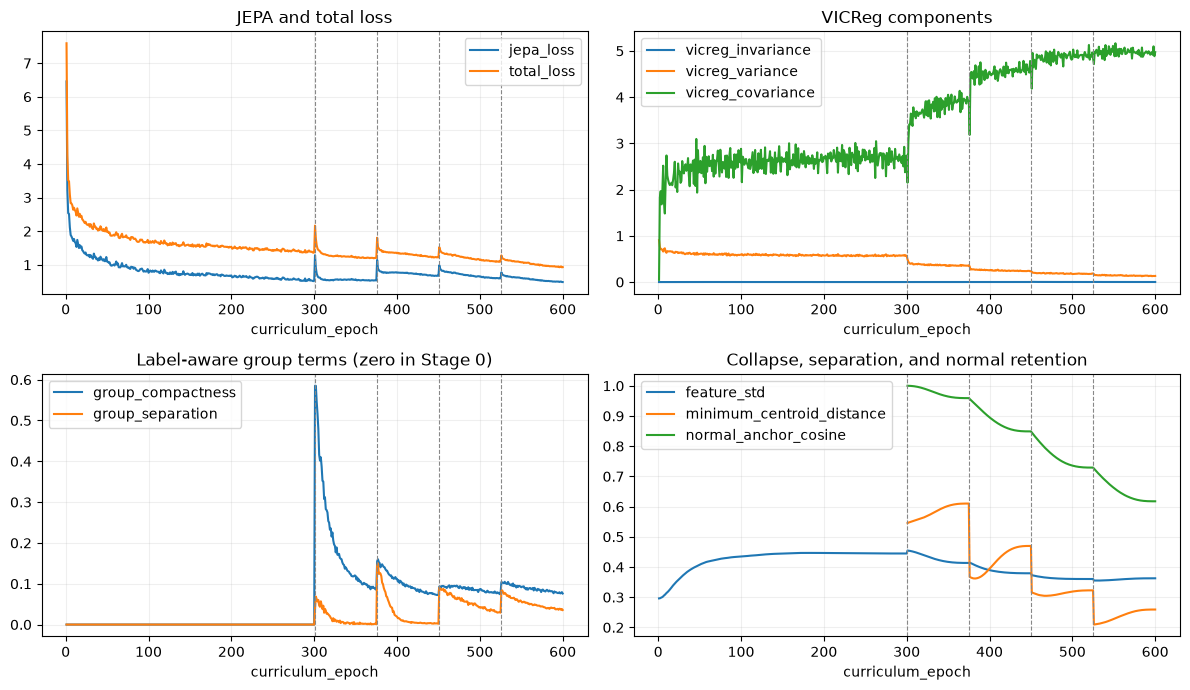

In [16]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history_rows).reset_index(drop=True)
history_df["curriculum_epoch"] = np.arange(1, len(history_df) + 1)
figure, axes = plt.subplots(2, 2, figsize=(12, 7))
history_df.plot(x="curriculum_epoch", y=["jepa_loss", "total_loss"], ax=axes[0, 0])
history_df.plot(x="curriculum_epoch", y=["vicreg_invariance", "vicreg_variance", "vicreg_covariance"], ax=axes[0, 1])
history_df.plot(x="curriculum_epoch", y=["group_compactness", "group_separation"], ax=axes[1, 0])
history_df.plot(x="curriculum_epoch", y=["feature_std", "minimum_centroid_distance", "normal_anchor_cosine"], ax=axes[1, 1])
axes[0, 0].set_title("JEPA and total loss")
axes[0, 1].set_title("VICReg components")
axes[1, 0].set_title("Label-aware group terms (zero in Stage 0)")
axes[1, 1].set_title("Collapse, separation, and normal retention")
for axis in axes.flat:
    for boundary in history_df.groupby("stage")["curriculum_epoch"].min().iloc[1:]:
        axis.axvline(boundary - 0.5, color="#888888", linestyle="--", linewidth=0.8)
    axis.grid(alpha=0.2)
figure.tight_layout()
figure.savefig(
    ARTIFACT_DIR / cohort_artifact_name("curriculum_training_diagnostics.png", augmented=bool(aug_records)),
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Summary: what was established, and how to read it without overclaiming

### What this notebook established

1. A five-stage S-JEPA curriculum ran to completion on the recorded 159-sequence, 35-video corpus, at 600 epochs and 11,400 optimizer updates, with a complete checkpoint parent chain ending at fingerprint `ea59fea055f0230bcf236deb1d1e8bbf08033766e7cd95a98f28210b3042c4e4`.
2. The final representation did not totally collapse: feature spread ended at 0.363, away from zero, and mean pair cosine ended at 0.660, away from one.
3. Later stages caused substantial normal-anchor drift, from 0.959 after Stage 1 to 0.617 after Stage 4, despite balanced replay.
4. The label-aware margin was **not** met at the end. The margin penalty rose to 0.0357 and the minimum training centroid distance fell to 0.259.
5. The augmented-normal cohort was selected by a recorded rule rather than by directory contents: 64 audited candidates, 63 accepted at a coverage threshold of 0.45, one rejected at coverage 0.027.

### How to read each diagnostic

- A finite or falling JEPA loss says the predictor is matching the teacher better. It does not prove useful gait semantics.
- A feature standard deviation near zero, a VICReg variance hinge that stays high, or a pairwise cosine near one would each warn about collapse. None of those happened, which rules collapse out and rules nothing in.
- The minimum centroid distance must be read together with within-condition compactness. Even a margin penalty near zero would mean only that the training constraint was satisfied on this corpus, not that unseen people would separate. Here the penalty was not near zero.
- `normal_anchor_cosine` tracks how far the normal representation moved after each added condition. A sharp fall suggests forgetting despite replay, and that is what we observed.
- Stage 0 is label-free with respect to condition separation. Stages 1 through 4 are label-aware, because the group loss reads folder annotations. Folder labels are dataset annotations, not clinical diagnoses.

### What remains open

- Existing repository metrics from the earlier 10-keypoint, normal-only checkpoint are a legacy baseline, not results for this model. Do not report new accuracy, robustness, or capacity claims until notebooks 04 through 06 have been rerun and the checkpoint fingerprint is recorded.
- Because the final encoder saw the whole progressive corpus **and** its condition labels, any classifier fitted on those same rows is a descriptive readout, not a held-out generalization test. All results downstream of this notebook are **transductive**. A valid generalization estimate requires splitting by source video before all preprocessing and representation training, and then fitting the entire five-stage curriculum inside each outer training fold.
- The source video, not the sequence, is the independent unit of evidence. This corpus has 35 source videos in total and only 18 for normal, so the number of independent units is far smaller than the 159 rows suggest.

### Next notebook

**05_inspect_latent_motion.ipynb** loads `sjepa_curriculum_final_augmented.pt` and asks what the geometry actually looks like. It separates two claims that this notebook cannot separate: evidence that the run did not collapse, and evidence that the conditions are separable. Those turn out to have very different answers.
